In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier

In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
x=1471+139
print('x=',x)

x= 1610


In [5]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [6]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF18aaxalmu,15.005307,15.005451,0.145935,14.993530,0.597476,0.341786,0.184505,0.407814,0.523393,...,0.551990,455.259249,0.070098,0.473539,0.655574,0.009726,36.479324,75.199451,-0.216893,0.728315
1,ZTF18abdktdm,13.732480,13.730841,0.200683,13.677447,1.642571,0.280521,0.139074,0.438177,11.892518,...,0.733768,4745.717813,0.114399,0.627572,2.253129,0.014614,20.504447,140.509623,1.290197,0.780460
2,ZTF18aayvgbc,17.726470,17.684295,0.229726,17.814396,0.739251,0.321292,0.196507,0.610500,-0.332109,...,0.658829,1066.014702,0.124237,0.350301,0.773573,0.012959,52.658819,75.402594,-0.709159,0.847938
3,ZTF18aawadfz,13.492420,13.492705,0.166461,13.489174,1.211679,0.223365,0.366470,0.386705,14.581503,...,0.751039,205.187118,0.140327,0.364438,1.999977,0.012337,43.679944,128.055308,0.915288,0.834133
4,VZ Sex,15.711770,15.696002,0.453383,15.756104,1.798687,0.183119,0.135096,0.831679,7.887024,...,0.530765,511.649845,0.175695,0.507868,2.463995,0.028856,27.332548,1268.450608,-2.053008,0.651210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,ZTF18aayvgby,16.966766,16.703003,0.753429,16.867558,1.952743,0.282646,0.202763,2.222405,0.291822,...,0.438594,313.350371,0.404953,0.371962,2.057354,0.044406,45.319260,816.868630,0.596512,0.802344
1606,ZTF18aayvhgz,14.359551,14.358874,0.151752,14.343392,1.285771,0.248777,0.253027,0.335245,15.969538,...,0.659004,1685.568656,0.093006,0.684137,1.871861,0.010568,13.642137,72.866616,1.770519,0.763827
1607,ZTF18admcunq,15.981421,15.957788,0.267171,15.960569,0.829372,0.271582,0.248937,0.792974,0.141180,...,0.409190,1308.393168,0.131795,0.204789,0.981176,0.016718,22.386824,200.569961,0.489161,0.781984
1608,V2467 Cyg,17.747432,17.735122,0.102866,17.754228,1.209559,0.167857,0.125264,0.188236,156.988180,...,0.637770,209.542109,0.048647,0.883929,2.112926,0.005796,27.137568,33.199411,-8.001418,0.452335


In [7]:
#X
X = df.drop(columns=['object']).values

In [8]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [9]:
print(np.unique(y))


[-1  1]


In [10]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [11]:
print(np.unique(y))


[0 1]


In [12]:
#now we'll run a step-by-step code to implement most accurate number os trees in my random(n_estimator value) and test train split(test_size) and other important xgb boost parameters
train_sizes = np.arange(0.5, 0.91, 0.1) #train size
n_estimators = np.arange(50, 201, 20) #number of trees
max_depth = np.arange(1,11,1) #number of nodes in trees
learning_rate= np.arange(0.0, 0.11, 0.01) #contribution of each tree
#other parameters we took as default
results = []
#test-train split array
for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        #stratify=y
    )

    for n in n_estimators:
        for depth in max_depth:
            for lr in learning_rate:
#our model
                model = XGBClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    learning_rate=lr,
                    eval_metric='logloss', #As it is a good choice for classification with probabilistic outputs,otherwise  loss ‘exponential’, gradient boosting recovers the AdaBoost algorithm
                    #random_state=42 #I want ifferent random run in each run
                )

                model.fit(X_train, y_train) #model fit

                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred) #accuracy score
#results
                results.append({
                    "train_size": size,
                    "n_estimators": n,
                    "max_depth": depth,
                    "learning_rate": lr,
                    "accuracy": acc
                })

results_df = pd.DataFrame(results)



In [13]:
#check
results_df

,train_size,n_estimators,max_depth,learning_rate,accuracy
0,0.5,50,1,0.00,0.924224
1,0.5,50,1,0.01,0.924224
2,0.5,50,1,0.02,0.924224
3,0.5,50,1,0.03,0.945342
4,0.5,50,1,0.04,0.952795
...,...,...,...,...,...
4395,0.9,190,10,0.06,0.950617
4396,0.9,190,10,0.07,0.956790
4397,0.9,190,10,0.08,0.956790
4398,0.9,190,10,0.09,0.950617


In [14]:
#find best configuration
best_row = results_df.loc[results_df["accuracy"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth= best_row["max_depth"]
best_learning_rate= best_row["learning_rate"]
best_accuracy = best_row["accuracy"]

print("Best configuration:")
print(f"Train size      : {best_train_size}")
print(f"n_estimators    : {best_n_estimators}")
print(f"max_depth       :{best_max_depth}")
print(f"learning_rate    :{best_learning_rate}")
print(f"Test accuracy   : {best_accuracy:.4f}")


Best configuration:
Train size      : 0.7999999999999999
n_estimators    : 90.0
max_depth       :10.0
learning_rate    :0.07
Test accuracy   : 0.9783


In [29]:
best_accuracy = results_df["accuracy"].max()

best_rows = results_df[results_df["accuracy"] == best_accuracy]

print(best_rows)
best_rows.to_csv('best_configuration.csv')

      train_size  n_estimators  max_depth  learning_rate  accuracy
2966         0.8            90         10           0.07  0.978261
3002         0.8           110          3           0.10  0.978261
3076         0.8           110         10           0.07  0.978261
3112         0.8           130          3           0.10  0.978261
3120         0.8           130          4           0.07  0.978261
3186         0.8           130         10           0.07  0.978261
3221         0.8           150          3           0.09  0.978261
3229         0.8           150          4           0.06  0.978261
3230         0.8           150          4           0.07  0.978261
3296         0.8           150         10           0.07  0.978261
3331         0.8           170          3           0.09  0.978261
3332         0.8           170          3           0.10  0.978261
3340         0.8           170          4           0.07  0.978261
3406         0.8           170         10           0.07  0.97

In [16]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
   # random_state=42
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=90, n_jobs=-1,
              num_parallel_tree=None, ...)

In [17]:
#predict model
y_pred = best_model.predict(X_test)
print(y_pred)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [18]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9627329192546584


In [28]:
probs = best_model.predict_proba(X_test)
print('probs',probs)

probs [[9.99077797e-01 9.22214473e-04]
 [9.99008477e-01 9.91509645e-04]
 [9.99254823e-01 7.45155383e-04]
 [9.98912036e-01 1.08795369e-03]
 [9.98992205e-01 1.00778847e-03]
 [9.98765707e-01 1.23429170e-03]
 [9.98113453e-01 1.88655092e-03]
 [2.04160094e-01 7.95839906e-01]
 [9.98212636e-01 1.78739126e-03]
 [9.94860232e-01 5.13976719e-03]
 [9.92546558e-01 7.45346490e-03]
 [9.98776376e-01 1.22363935e-03]
 [9.94125247e-01 5.87477721e-03]
 [9.97059166e-01 2.94085057e-03]
 [9.96015549e-01 3.98444384e-03]
 [9.98982430e-01 1.01759844e-03]
 [2.71313190e-02 9.72868681e-01]
 [9.98937190e-01 1.06280542e-03]
 [9.90040064e-01 9.95992031e-03]
 [9.95232522e-01 4.76745795e-03]
 [9.98411000e-01 1.58897159e-03]
 [9.99250591e-01 7.49387837e-04]
 [3.35549116e-02 9.66445088e-01]
 [9.98200893e-01 1.79909344e-03]
 [9.98441875e-01 1.55810348e-03]
 [9.99345660e-01 6.54337637e-04]
 [9.99258876e-01 7.41144177e-04]
 [1.94824159e-01 8.05175841e-01]
 [9.91925359e-01 8.07465799e-03]
 [8.81505609e-02 9.11849439e-01]
 [9.

Confusion matrix (raw counts):
[[288   6]
 [  6  22]]


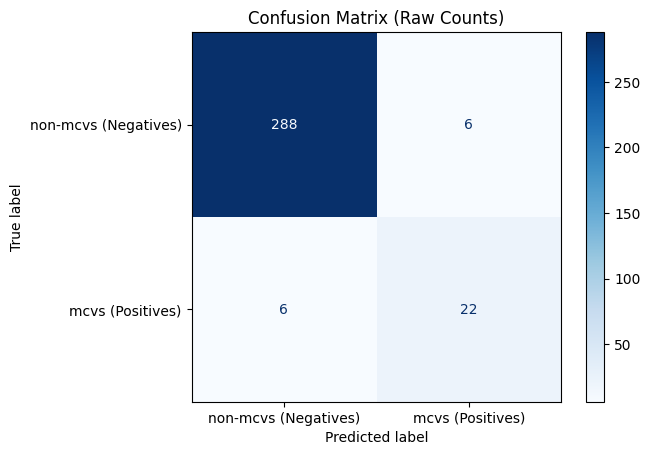

In [19]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [20]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model.pkl")

['cv_classifier_best_model.pkl']

In [31]:
#from this cell our prev work
# last used hyperparameters
train_size = 0.70
n_estimators = 130
#oter parameters were not varied
# Final train-test split
X_train_prev, X_test_prev, y_train_prev, y_test_prev = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    #random_state=42
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=130,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss' 
)

final_model.fit(X_train_prev, y_train_prev)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=130, n_jobs=-1,
              num_parallel_tree=None, ...)

In [32]:
#training set
final_model.fit(X_train_prev, y_train_prev)

print("Model trained successfully")


Model trained successfully


In [33]:
#predict model
y_pred = final_model.predict(X_test_prev)
print(y_pred)


[1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0
 0 0]


In [34]:
#accuracy
print("Accuracy:", accuracy_score(y_test_prev, y_pred))


Accuracy: 0.9606625258799172


In [35]:
probs = best_model.predict_proba(X_test_prev)
print('probs',probs)

probs [[1.64676905e-02 9.83532310e-01]
 [9.99322951e-01 6.77057425e-04]
 [9.98468637e-01 1.53137778e-03]
 [9.98319268e-01 1.68070395e-03]
 [9.94626045e-01 5.37393941e-03]
 [9.97833490e-01 2.16652150e-03]
 [9.98704553e-01 1.29544479e-03]
 [9.98966277e-01 1.03371311e-03]
 [3.31918001e-02 9.66808200e-01]
 [9.98183310e-01 1.81669334e-03]
 [9.98086631e-01 1.91334763e-03]
 [9.99031126e-01 9.68848763e-04]
 [9.99296963e-01 7.03026133e-04]
 [9.99131501e-01 8.68518313e-04]
 [1.29881501e-02 9.87011850e-01]
 [6.48328662e-02 9.35167134e-01]
 [9.96985376e-01 3.01461271e-03]
 [9.98398423e-01 1.60155434e-03]
 [9.56119061e-01 4.38809544e-02]
 [9.98384237e-01 1.61578972e-03]
 [9.97320712e-01 2.67929165e-03]
 [9.99112427e-01 8.87545233e-04]
 [9.97829318e-01 2.17067567e-03]
 [9.99181807e-01 8.18187313e-04]
 [9.65222239e-01 3.47777605e-02]
 [9.98941541e-01 1.05848070e-03]
 [9.98615921e-01 1.38410239e-03]
 [9.99064565e-01 9.35411721e-04]
 [7.21766949e-02 9.27823305e-01]
 [9.95341182e-01 4.65882989e-03]
 [9.

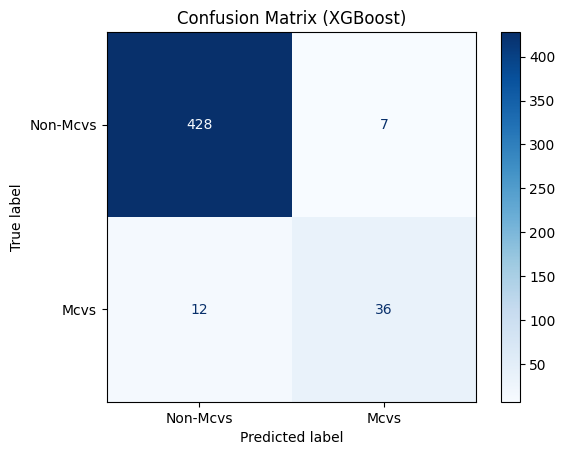

In [36]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test_prev, y_pred, labels=[0, 1])

class_names = ["Non-Mcvs", "Mcvs"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
# Save the figure to your current directory
plt.savefig('confusion matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 428 FP: 7 FN: 12 TP: 36


In [38]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost_biggie_set.pkl")

['cv_classifier_xgb_boost_biggie_set.pkl']